## Exercise 1

Complete the missing components of the following cells.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load MNIST data
mnist = fetch_openml("mnist_784", version=1)
X, y = mnist["data"].values, mnist["target"].astype(int).values

# Sample the dataset to speed up computation (Optional)
X, y = X[:7000], y[:7000]

# Split the dataset
X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Visualize using PCA (2 components)
# Reduce the data with PCA
pca = PCA()

# You need to populate the following variable after you've defined a PCA object
X_mnist_reduced = pca.fit_transform(X_mnist_train)

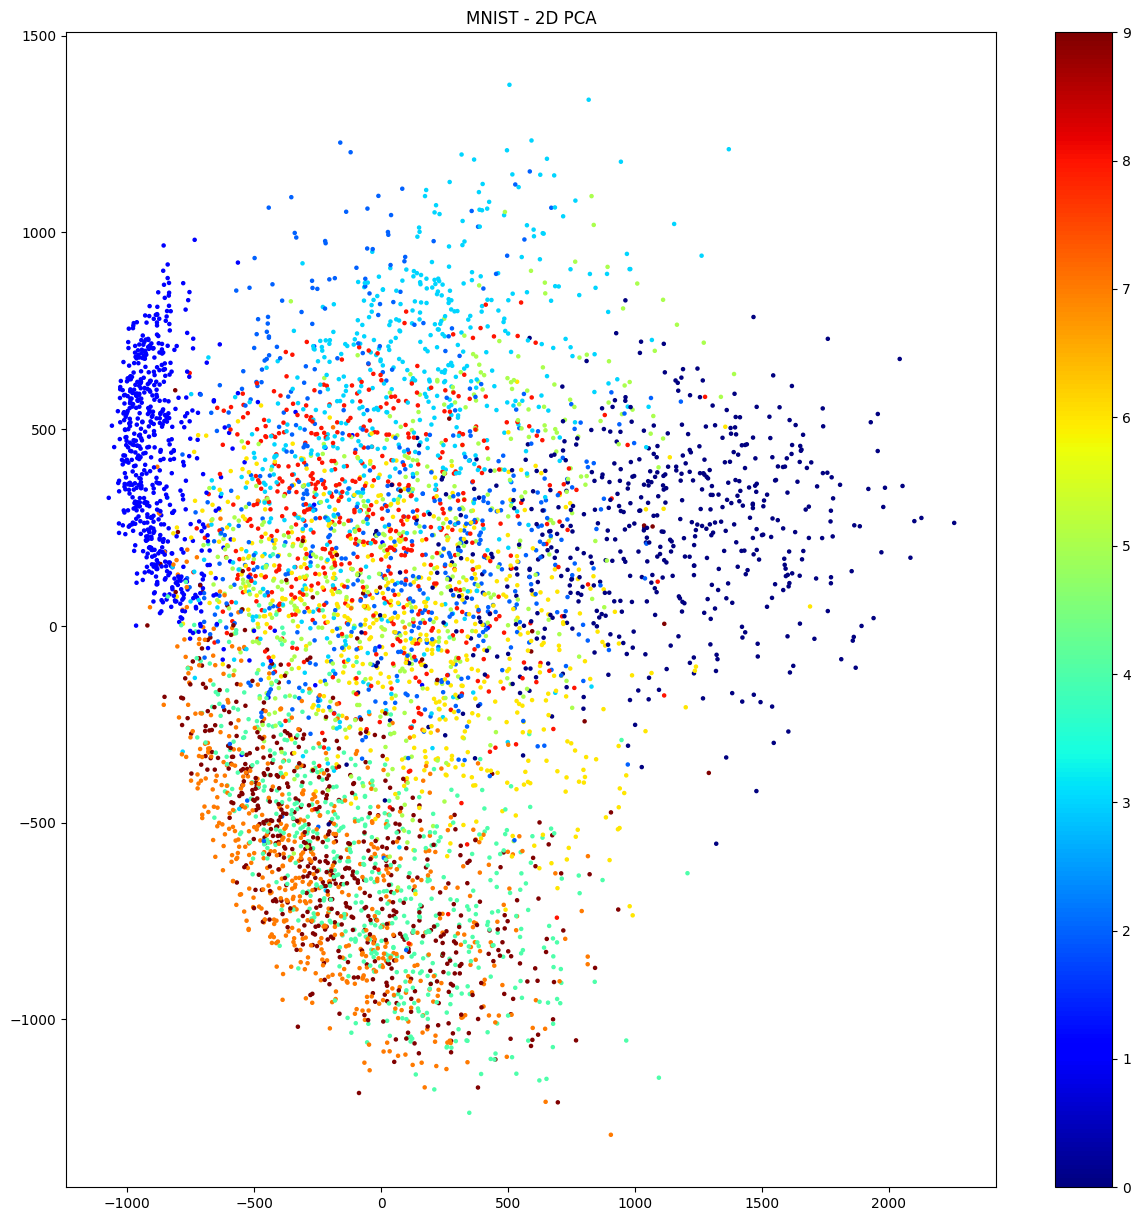

In [ ]:
# Now plotting
plt.figure(figsize=(15,15))
plt.scatter(X_mnist_reduced[:, 0], X_mnist_reduced[:, 1], c=y_mnist_train, cmap="jet",s=5)
plt.colorbar()
plt.title("MNIST - 2D PCA")
plt.show()

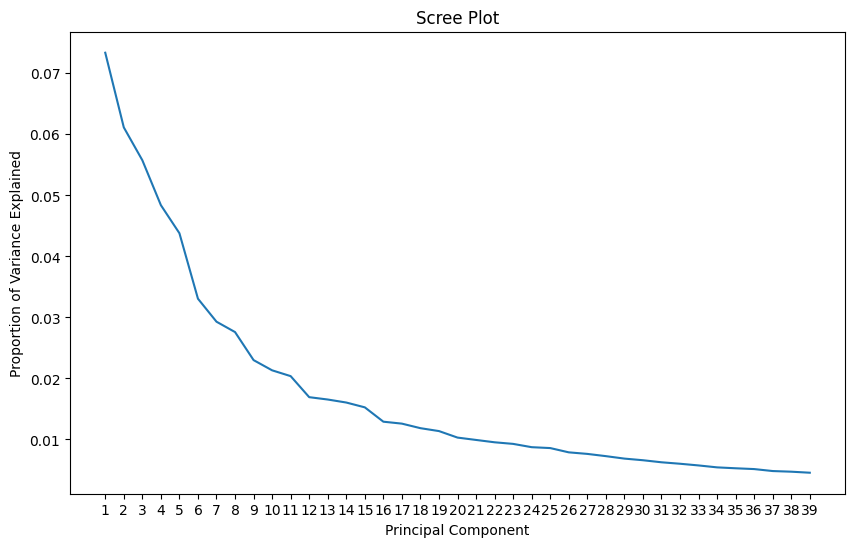

In [ ]:
# Step 3: Scree Plot
variance_explained = pca.explained_variance_ratio_[1:40]

# Step 4: Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variance_explained) + 1), variance_explained)
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.xticks(range(1, len(variance_explained) + 1))
plt.show()

In [5]:
cumulative_variance_explained = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components for desired explained variance
threshold = 0.95  # 95% variance
n_components = np.argmax(cumulative_variance_explained >= threshold) + 1
print(f"Number of components needed for {threshold*100}% variance: {n_components}")

Number of components needed for 95.0% variance: 148


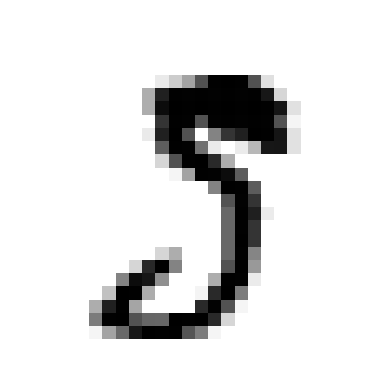

In [ ]:
def plot_mnist_digit(digit):
    """Plot a single MNIST digit.

    Parameters:
    digit (numpy array): A flattened 1D numpy array of length 784.

    """
    # Reshape the flattened digit to 28x28 image
    digit_image = digit.reshape(28, 28)

    plt.imshow(digit_image, cmap='binary')
    plt.axis("off")
    plt.show()

plot_mnist_digit(X_mnist_train[0])

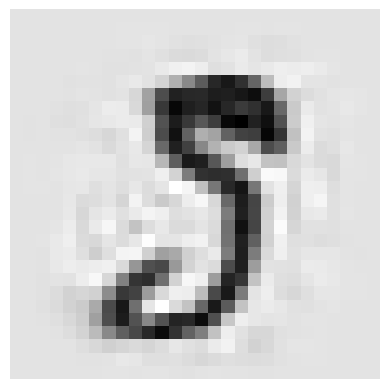

In [ ]:
# Step 5: Use PCA with n_components to transform the above digit.  How does it look?
pca_test = PCA(n_components=148)
xr = pca_test.fit_transform(X_mnist_train)
x_regen  = pca_test.inverse_transform(xr[0])
plot_mnist_digit(x_regen)

In [16]:
# Step 6: k-NN Classification
# Without PCA
knn = KNeighborsClassifier()
knn.fit(X_mnist_train, y_mnist_train)
y_pred = knn.predict(X_mnist_test)
print(f"Original Data Accuracy: {round(accuracy_score(y_mnist_test, y_pred), 3)}")

# With PCA
# You have some work to do right here
pca_knn = PCA(.85)
X_train_xf = pca_knn.fit_transform(X_mnist_train)
X_test_xf = pca_knn.transform(X_mnist_test)

knn = KNeighborsClassifier()
knn.fit(X_train_xf, y_mnist_train)
y_pred_pca = knn.predict(X_test_xf)
print(f"PCA-transformed Data Accuracy: {round(accuracy_score(y_mnist_test, y_pred_pca), 3)}")

Original Data Accuracy: 0.942
PCA-transformed Data Accuracy: 0.954


## Exercise 2

1. Try using t-SNE to visualize the MNIST data above.  How does it compare to PCA?
2. Try using a KNN classifier to predict the data with TSNE.  How does it perform?

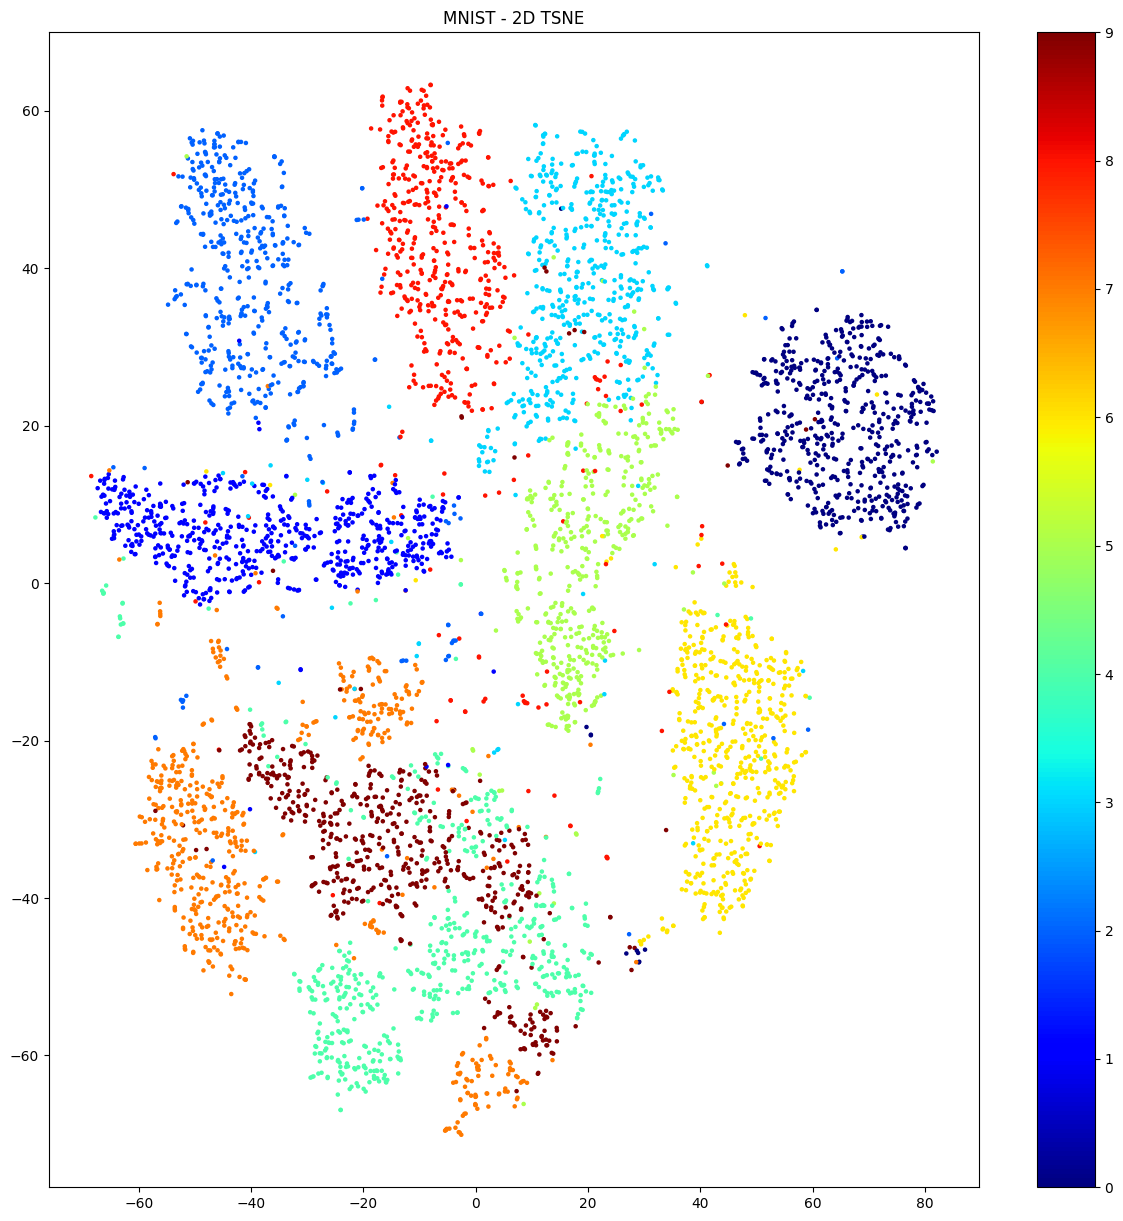

In [25]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X_mnist_train)

plt.figure(figsize=(15,15))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_mnist_train, cmap="jet", s=5)
plt.colorbar()
plt.title("MNIST - 2D TSNE")
plt.show()

In [26]:
X_tsne = tsne.fit_transform(X)


In [27]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(X_tsne, y, test_size=0.2, random_state=42)

In [28]:
knn = KNeighborsClassifier()
knn.fit(X_train_tsne, y_train_tsne)
y_pred_tsne = knn.predict(X_test_tsne)
print(f"TSNE-transformed Data Accuracy: {round(accuracy_score(y_test_tsne, y_pred_tsne), 3)}")

TSNE-transformed Data Accuracy: 0.941


## Exercise 3

Try using UMAP to process the MNIST data.  Visualize the data first, and then calculate accuracy with KNN.

In [20]:
%pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.8 MB/s eta 0:00:00


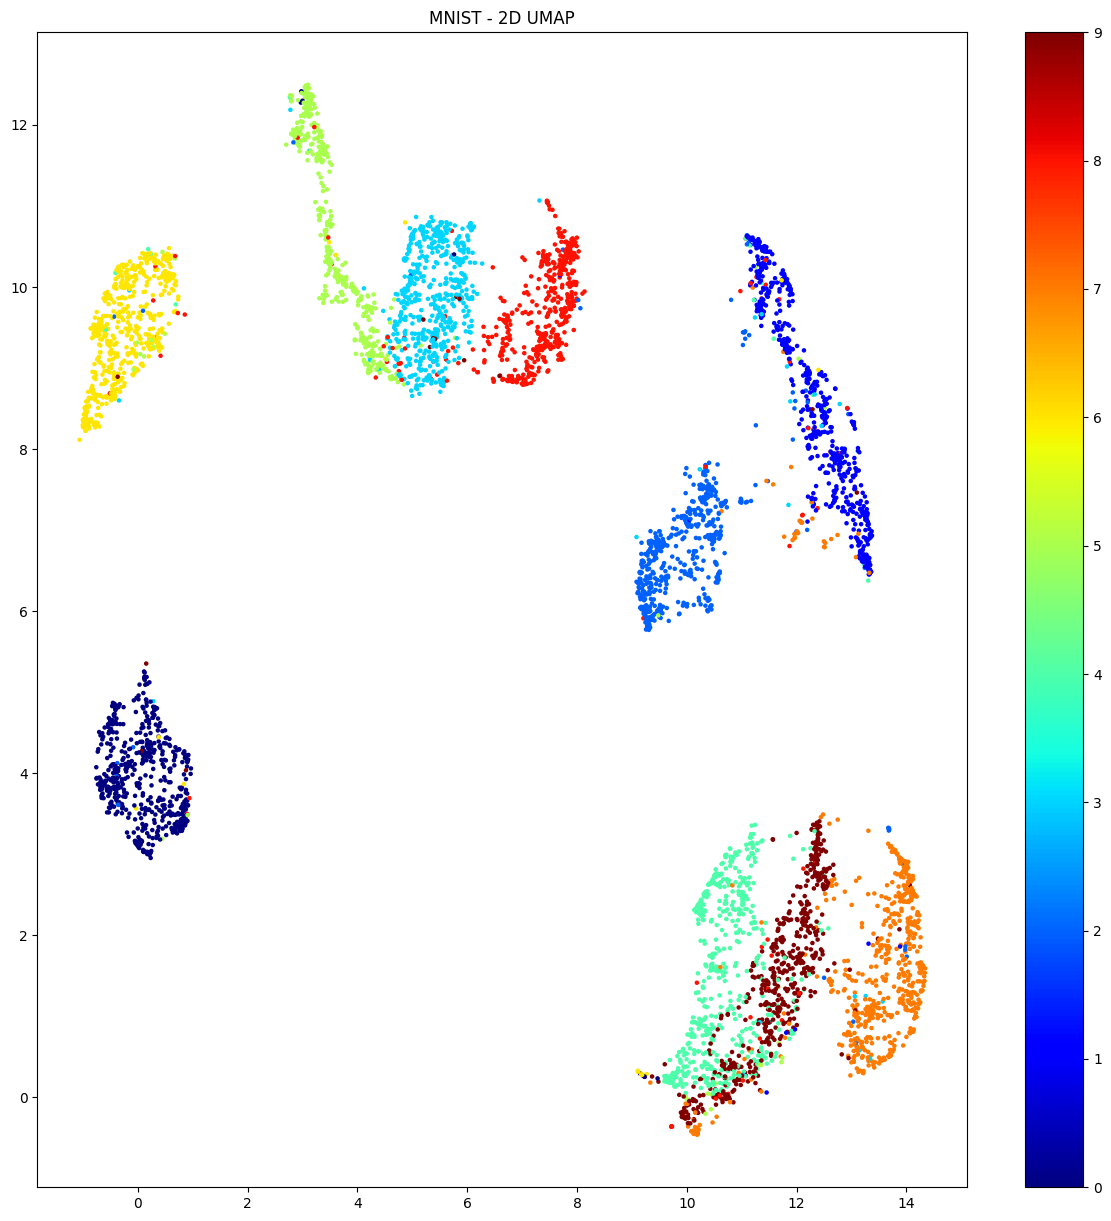

In [32]:
import umap
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.01, n_components=2)
X_umap_train = umap_model.fit_transform(X_mnist_train)
plt.figure(figsize=(15,15))
plt.scatter(X_umap_train[:, 0], X_umap_train[:, 1], c=y_mnist_train, cmap="jet",s=5)
plt.colorbar()
plt.title("MNIST - 2D UMAP")
plt.show()

In [33]:
X_umap_test = umap_model.transform(X_mnist_test)
knn = KNeighborsClassifier()
knn.fit(X_umap_train, y_mnist_train)
y_pred_umap = knn.predict(X_umap_test)
print(f"Umap-transformed Data Accuracy: {round(accuracy_score(y_mnist_test, y_pred_umap), 3)}")

Umap-transformed Data Accuracy: 0.878
